In [ ]:
# !pip install -r ../requirements.txt

In [ ]:
import re
from tqdm import tqdm
import pandas as pd
import simple_icd_10 as icd
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1000)
pd.set_option('display.max_colwidth', None)

In [ ]:
df = pd.read_csv("prepared_data.csv")

In [ ]:
df["admittime"] = pd.to_datetime(df["admittime"])
df["dischtime"] = pd.to_datetime(df["dischtime"])
df["deathtime"] = pd.to_datetime(df["deathtime"])

In [ ]:
df.head()

,Unnamed: 0,subject_id,hadm_id,seq_num,icd_code,icd_version,icd10_code,icd10_category,admittime,dischtime,deathtime,is_oncology,category
0,0,10000032,22595853,1,5723,9,K766,K76,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,0,K76
1,1,10000032,22595853,2,78959,9,R188,R18,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,0,R18
2,2,10000032,22595853,3,5715,9,K740,K74,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,0,K74
3,3,10000032,22595853,4,07070,9,B1920,B19,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,0,B19
4,4,10000032,22595853,5,496,9,J449,J44,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,0,J44


### how many cancers

In [ ]:
def is_onco(code: str) -> int:
    """
    Malignant neoplasms  C00–C97
    In-situ + uncertain   D00–D09, D37–D48
    Берём три ведущих символа и проверяем диапазоны.
    """
    c = code.upper()
    if c[0] == "C":
        return 1
    if re.match(r"D0[0-9]|D[3-4][7-8]", c):
        return 1
    return 0

In [ ]:
df[df["is_oncology"]==1]["subject_id"].nunique()

32972

In [ ]:
cancers_statistics = df[df["is_oncology"]==1][["icd10_category", "subject_id"]].drop_duplicates().groupby("icd10_category").agg({"subject_id": "count"}).sort_values("subject_id", ascending=False)
cancers_statistics["description"] = [icd.get_description(x) if icd.is_valid_item(x) else None for x in cancers_statistics.index]

In [ ]:
cancers_statistics

,subject_id,description
icd10_category,,
C78,7724,Secondary malignant neoplasm of respiratory and digestive organs
C79,7534,Secondary malignant neoplasm of other and unspecified sites
C77,4907,Secondary and unspecified malignant neoplasm of lymph nodes
C34,4215,Malignant neoplasm of bronchus and lung
D47,3554,"Other neoplasms of uncertain or unknown behaviour of lymphoid, haematopoietic and related tissue"
C61,2497,Malignant neoplasm of prostate
C50,2225,Malignant neoplasm of breast
C25,1958,Malignant neoplasm of pancreas
C22,1771,Malignant neoplasm of liver and intrahepatic bile ducts


### admissions

In [ ]:
admissions_number = df.groupby(by='subject_id').apply(lambda x: x['hadm_id'].nunique())
admissions_number = pd.DataFrame({"subject_id": admissions_number.index, "n_admissions": admissions_number.values})

/tmp/ipykernel_157256/2946225359.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  admissions_number = df.groupby(by='subject_id').apply(lambda x: x['hadm_id'].nunique())


In [ ]:
len(admissions_number[admissions_number["n_admissions"] > 1])

100057

In [ ]:
admissions_number[admissions_number["n_admissions"] > 1]["n_admissions"].mean()

np.float64(4.220224472050931)

<Axes: >

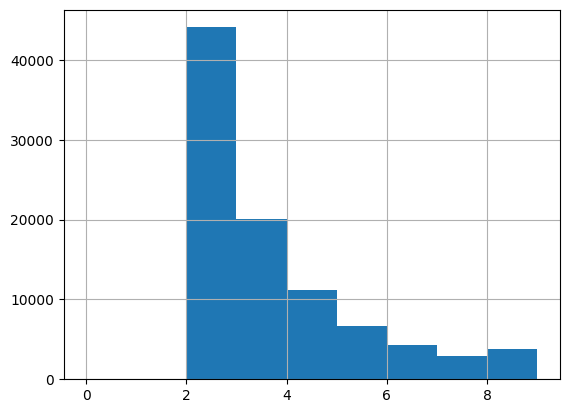

In [ ]:
admissions_number[admissions_number["n_admissions"] > 1]["n_admissions"].hist(bins=range(10))

### Cancers statistics

In [ ]:
from functools import partial

def get_history_before_event(patient_df, target="C34"):
    if target not in patient_df["icd10_category"].values:
        return None
    else:
        patient_df = patient_df.sort_values(["admittime", "dischtime", "seq_num"]).reset_index(drop=True)
        target_index = patient_df[patient_df["icd10_category"] == target].index[0]
        target_admission = patient_df[patient_df["icd10_category"] == target].iloc[0]["hadm_id"]
        prev_patient_df = patient_df.loc[:target_index]
        prev_patient_df = prev_patient_df[prev_patient_df["hadm_id"] != target_admission]
        return prev_patient_df
    
def is_target_first(patient_df, target="C34"):
    prev_patient_df = get_history_before_event(patient_df, target=target)
    if prev_patient_df is not None:
        return not prev_patient_df["icd10_category"].apply(is_onco).any()
    else:
        return True

def n_admissions_before_event(patient_df, target="C34"):
    prev_patient_df = get_history_before_event(patient_df, target=target)
    if prev_patient_df is not None:
        return prev_patient_df["hadm_id"].nunique()
    else:
        return None
    
def n_codes_before_event(patient_df, target="C34"):
    prev_patient_df = get_history_before_event(patient_df, target=target)
    if prev_patient_df is not None:
        return prev_patient_df["icd10_code"].nunique()
    else:
        return None
    
def timedelta_to_event(patient_df, target="C34"):
    if target not in patient_df["icd10_category"].values:
        return None
    else:
        patient_df = patient_df.sort_values(["admittime", "dischtime", "seq_num"]).reset_index(drop=True)
        target_data = patient_df[patient_df["icd10_category"] == target].iloc[0]["admittime"]
        first_data = patient_df.iloc[0]["admittime"]
        return (target_data - first_data).days

def get_statistics(df, target="C34"):
    res = {}
    target_patients = list(df[df["icd10_category"] == target]["subject_id"].unique())
    res["total_patients_number"] = len(target_patients)
    target_patients = df[df["subject_id"].isin(target_patients)].groupby("subject_id").apply(is_target_first)
    target_patients = list(target_patients[target_patients].index)
    res["cancer_first_patients"] = len(target_patients)

    target_dataset = df[df["subject_id"].isin(target_patients)]

    admissions_before_event = target_dataset.groupby("subject_id").apply(partial(n_admissions_before_event, target=target))
    admissions_before_event = admissions_before_event[admissions_before_event > 0]
    for i in range(1, 3):
        res[f"n_pats_adms_before_event>={i}"] = (admissions_before_event >= i).sum()
    res["avg_n_adms_before_event>=1"] = admissions_before_event.mean()
    res["med_n_adms_before_event>=1"] = admissions_before_event.median()
    res["min_n_adms_before_event>=1"] = admissions_before_event.min()
    res["max_n_adms_before_event>=1"] = admissions_before_event.max()

    codes_before_event = target_dataset.groupby("subject_id").apply(partial(n_codes_before_event, target=target))
    codes_before_event = codes_before_event[codes_before_event.index.isin(admissions_before_event.index)]
    res["avg_n_codes_before_event_n_adms>=1"] = codes_before_event.mean()
    res["med_n_codes_before_event_n_adms>=1"] = codes_before_event.median()
    res["min_n_codes_before_event_n_adms>=1"] = codes_before_event.min()    
    res["max_n_codes_before_event_n_adms>=1"] = codes_before_event.max()

    timedeltas_to_event = target_dataset.groupby("subject_id").apply(partial(timedelta_to_event, target=target))
    timedeltas_to_event = timedeltas_to_event[timedeltas_to_event.index.isin(admissions_before_event.index)]
    res["avg_timedelta_to_event"] = timedeltas_to_event.mean()
    res["med_timedelta_to_event"] = timedeltas_to_event.median()
    res["min_timedelta_to_event"] = timedeltas_to_event.min()    
    res["max_timedelta_to_event"] = timedeltas_to_event.max()

    # admissions = target_dataset.groupby("subject_id").apply(lambda x: x["hadm_id"].nunique())
    # admissions = admissions[admissions > 1]
    # for i in range(2, 4):
    #     res[f"n_pats_adms>={i}"] = (admissions >= i).sum()
    # res["avg_n_adms>=2"] = admissions.mean()
    # res["med_n_adms>=2"] = admissions.median()
    # res["min_n_adms>=2"] = admissions.min()
    # res["max_n_adms>=2"] = admissions.max()

    # codes = target_dataset.groupby("subject_id").apply(lambda x: x["icd10_code"].nunique())
    # codes = codes[codes.index.isin(admissions.index)]
    # res["avg_n_codes_adms>=2"] = codes.mean()
    # res["med_n_codes_adms>=2"] = codes.median()
    # res["min_n_codes_adms>=2"] = codes.min()    
    # res["max_n_codes_adms>=2"] = codes.max()

    return res

In [ ]:
from multiprocessing import Pool
import multiprocessing

def get_row(target):
    target_res = {
        "ICD10 code": target,
        "Description": icd.get_description(target) if icd.is_valid_item(target) else None,
    }
    target_res.update(get_statistics(df, target))
    return target_res

n_codes = 20
codes = []
for code, row in cancers_statistics.iterrows():
    if "other" not in row["description"].lower() and "unknown" not in row["description"].lower() and "secondary" not in row["description"].lower():
        codes.append(code)
        if len(codes) == n_codes:
            break
print(codes)

res = []
with Pool(processes=n_codes) as pool:
    pb = tqdm(
        pool.imap(get_row, codes),
        total=n_codes
    )
    for target_res in pb:
        pb.set_description(target_res["ICD10 code"])
        res.append(target_res)

cancers_statistics_full = pd.DataFrame(res)

['C34', 'C61', 'C50', 'C25', 'C22', 'C18', 'C64', 'C80', 'C83', 'C91', 'C67', 'C92', 'C90', 'C71', 'C54', 'C16', 'C56', 'C73', 'C15', 'C20']


  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_194661/3507832575.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  target_patients = df[df["subject_id"].isin(target_patients)].groupby("subject_id").apply(is_target_first)
/tmp/ipykernel_194661/3507832575.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  target_patients = df[df["subject_id"].isin(target_patients)].groupby("subject_id").apply(is_target_first

In [19]:
cancers_statistics_full

,ICD10 code,Description,total_patients_number,cancer_first_patients,n_pats_adms_before_event>=1,n_pats_adms_before_event>=2,avg_n_adms_before_event>=1,med_n_adms_before_event>=1,min_n_adms_before_event>=1,max_n_adms_before_event>=1,avg_n_codes_before_event_n_adms>=1,med_n_codes_before_event_n_adms>=1,min_n_codes_before_event_n_adms>=1,max_n_codes_before_event_n_adms>=1,avg_timedelta_to_event,med_timedelta_to_event,min_timedelta_to_event,max_timedelta_to_event
0,C34,Malignant neoplasm of bronchus and lung,4215,3790,1015,484,2.609852,1.0,1,44,19.065025,13.0,1,155,1325.133005,1015.0,1,5192
1,C61,Malignant neoplasm of prostate,2497,2465,897,476,2.715719,2.0,1,54,19.767001,14.0,1,156,1342.054627,927.0,1,5243
2,C50,Malignant neoplasm of breast,2225,2196,787,409,2.745870,2.0,1,48,18.059720,12.0,1,175,1486.022872,1209.0,0,5213
3,C25,Malignant neoplasm of pancreas,1958,1945,683,297,2.215227,1.0,1,46,17.106881,12.0,1,124,932.588580,335.0,1,4941
4,C22,Malignant neoplasm of liver and intrahepatic bile ducts,1771,1753,670,406,3.683582,2.0,1,88,24.895522,18.0,1,251,1050.234328,614.0,0,5248
5,C18,Malignant neoplasm of colon,1403,1385,543,269,2.583794,1.0,1,22,18.990792,13.0,1,135,1068.311234,640.0,1,5061
6,C64,"Malignant neoplasm of kidney, except renal pelvis",1291,1271,526,271,3.095057,2.0,1,55,22.868821,15.0,1,195,1241.216730,777.5,3,5264
7,C80,"Malignant neoplasm, without specification of site",1118,1066,605,384,3.798347,2.0,1,92,26.925620,18.0,1,311,986.504132,526.0,1,5034
8,C83,Non-follicular lymphoma,1050,1038,526,318,3.585551,2.0,1,28,24.480989,17.0,1,150,1065.378327,513.0,4,5085
9,C91,Lymphoid leukaemia,1034,1018,264,134,2.890152,2.0,1,29,21.492424,15.0,1,142,1391.371212,1113.0,0,4816
